# Multi-Agent System con LangGraph

Sistema supervisor + 3 agentes especializados (researcher, analyst, coder) usando LangGraph y OpenRouter.



## ¿Qué es un Sistema Multi-Agente con LangGraph?

Un **sistema multi-agente** (MAS) es un sistema compuesto por múltiples agentes inteligentes que interactúan entre sí para lograr objetivos comunes o individuales. En el contexto de la Inteligencia Artificial, estos agentes pueden ser modelos de lenguaje (LLMs) con roles y responsabilidades específicas, como investigar, analizar datos o generar código. La interacción y colaboración entre estos agentes permiten abordar problemas complejos de manera más eficiente y robusta que un solo agente.

**LangGraph** es una librería de LangChain que facilita la construcción de estos sistemas multi-agente complejos, permitiendo definir el flujo de trabajo como un grafo. Cada nodo en el grafo representa un agente o una acción, y las aristas definen las transiciones entre estos nodos. LangGraph proporciona:

1.  **Orquestación**: Define cómo los agentes interactúan y en qué orden.
2.  **Manejo de estado**: Permite que los agentes compartan y actualicen información a medida que el proceso avanza.
3.  **Flexibilidad**: Facilita la creación de flujos de trabajo dinámicos donde la decisión del próximo paso puede basarse en la salida del agente anterior.

En este cuaderno, implementaremos un sistema multi-agente con un **supervisor** que dirige a **agentes especializados** (investigador, analista, codificador) para resolver una pregunta compleja. El supervisor decidirá qué agente es el más adecuado para cada etapa de la resolución del problema.

## 1. Instalación

Antes de comenzar, es necesario instalar las librerías `langgraph`, `langchain` y `langchain-openai`. Estas herramientas son fundamentales para construir y gestionar el sistema multi-agente.

In [1]:
!pip install -q -U langgraph langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 20.1 MB/s eta 0:00:00


## 2. Imports

Aquí importamos todas las clases y funciones necesarias. Esto incluye `os` y `json` para manejo de sistema y datos, `TypedDict` y `Annotated` para definir el estado del agente, y clases de `langchain_core.messages` para los distintos tipos de mensajes, además de `OpenAI` para la interacción con la API de OpenRouter.

In [2]:
import os
import json
from typing import Annotated, Literal, TypedDict

from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage

## 3. API Key

**En Colab:** descomentá la primera opción. **Local:** usá la segunda.

Esta sección configura la clave de API para OpenRouter. Es importante configurar esta clave de forma segura, ya sea a través de los secretos de Colab (Opción A) o como variable de entorno local (Opción B), para autenticar las llamadas a la API de los modelos de lenguaje.

In [3]:
# Opción A (Google Colab):
from google.colab import userdata
os.environ["OPENROUTER_KEY"] = userdata.get('OPENROUTER_KEY')

# Opción B (local / cualquier entorno):
# os.environ["OPENROUTER_KEY"] = input("OpenRouter API key: ")

OPENROUTER_API_KEY = os.getenv("OPENROUTER_KEY")
assert OPENROUTER_API_KEY, "No se encontró la API key. Configurá OPENROUTER_KEY primero."

## 4. Cliente de OpenRouter + conversor de mensajes

> ⚠️ Esta celda va **antes** de los nodos, porque los nodos la usan.

Aquí inicializamos el cliente de OpenAI para interactuar con la API de OpenRouter y definimos el nombre del modelo que utilizaremos. También incluimos una función auxiliar para convertir los mensajes de LangChain al formato que espera la API de OpenAI, lo cual es crucial para la comunicación entre LangChain y OpenRouter.

In [4]:
openrouter_client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

MODEL_NAME = "cohere/north-mini-code:free"


def convert_lc_messages_to_openai_format(lc_messages: list[BaseMessage]) -> list[dict]:
    """Convierte mensajes de LangChain al formato OpenAI.
    Los SystemMessage ya fueron 'aplanados' dentro del HumanMessage
    por flatten_system_and_agent_prompts."""
    openai_messages = []
    for msg in lc_messages:
        if isinstance(msg, HumanMessage):
            openai_messages.append({"role": "user", "content": msg.content})
        elif isinstance(msg, AIMessage):
            openai_messages.append({"role": "assistant", "content": msg.content})
    return openai_messages

## 5. Estado del grafo + helper de prompts

Definimos el estado del agente (`AgentState`) utilizando `TypedDict` para asegurar la tipificación y `Annotated` para el manejo automático de mensajes. También creamos una función `flatten_system_and_agent_prompts` para combinar los mensajes del sistema y del agente en un formato adecuado para el LLM, simplificando la estructura del prompt.

In [19]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next: str
    iterations: int   # ← NUEVO: contador anti-loop


def flatten_system_and_agent_prompts(messages: list[BaseMessage], agent_prompt: str) -> list[BaseMessage]:
    combined_instruction_content = agent_prompt
    modified_messages = []
    first_human_message_modified = False

    for msg in messages:
        if isinstance(msg, SystemMessage):
            combined_instruction_content += f"\n\n{msg.content}"
        elif isinstance(msg, HumanMessage) and not first_human_message_modified:
            modified_messages.append(
                HumanMessage(content=f"{combined_instruction_content}\n\n{msg.content}".strip())
            )
            first_human_message_modified = True
            combined_instruction_content = ""
        else:
            modified_messages.append(msg)

    if not first_human_message_modified and combined_instruction_content:
        modified_messages.insert(0, HumanMessage(content=combined_instruction_content.strip()))

    return modified_messages

## 6. Prompts de los agentes

Cada agente en nuestro sistema (researcher, analyst, coder y supervisor) tiene un prompt específico que define su rol y responsabilidades. Estos prompts guían su comportamiento y sus respuestas, asegurando que cada uno se enfoque en su área de especialización.

In [21]:
researcher_prompt = """
You are a research specialist.

Your job is to investigate the user's request,
identify relevant concepts, assumptions and facts,
and provide a concise research summary.

Do not write Python code unless explicitly necessary.
"""

analyst_prompt = """
You are a data analysis specialist.

Your job is to interpret data-related problems,
identify patterns, formulate hypotheses,
and propose appropriate statistical or machine learning approaches.

Focus on analytical reasoning.
Do not write implementation code unless necessary.
"""

coder_prompt = """
You are a Python programming specialist.

Your job is to design and write Python solutions
for data science problems.

Produce clear, correct and executable Python code.

Explain important implementation decisions briefly.
"""

supervisor_prompt = """
You are the supervisor of a team of specialized agents: researcher, analyst, coder.

Your job is to decide which agent should work next, based on the conversation history.

Rules:
1. Each agent's response is appended to the history. READ the latest agent response before deciding.
2. If the latest response already answers the user's question completely, return FINISH. Do NOT send the same agent again unless something is genuinely missing.
3. Send work to a DIFFERENT agent only if the task requires a different skill (e.g., after research comes analysis, after analysis comes code).
4. NEVER route to the same agent twice in a row.

Return a JSON object with a single key 'next':
{"next": "researcher"} | {"next": "analyst"} | {"next": "coder"} | {"next": "FINISH"}
"""

## 7. Función auxiliar para llamar al LLM

Evita repetir el mismo código en los 3 nodos.

Esta función genérica `call_agent_llm` se encarga de realizar la llamada al modelo de lenguaje (LLM) de OpenRouter. Toma el estado actual del agente y su prompt específico, formatea los mensajes y envía la solicitud al LLM, devolviendo la respuesta del modelo. Esto evita la repetición de código en los nodos individuales de cada agente.

In [22]:
def call_agent_llm(state: AgentState, agent_prompt: str) -> AIMessage:
    messages_for_llm = flatten_system_and_agent_prompts(state["messages"], agent_prompt)
    openai_messages_format = convert_lc_messages_to_openai_format(messages_for_llm)

    response = openrouter_client.chat.completions.create(
        model=MODEL_NAME,
        messages=openai_messages_format,
        temperature=0,
    )
    return AIMessage(content=response.choices[0].message.content)

## 8. Nodos de los agentes

Cada uno de estos nodos representa un agente especializado (investigador, analista, codificador). Cuando un agente es activado, llama a la función `call_agent_llm` con su prompt específico para generar una respuesta basada en el estado actual de los mensajes. Después de ejecutar su tarea, el control se devuelve al supervisor.

In [23]:
def researcher_node(state: AgentState):
    return {
        "messages": [call_agent_llm(state, researcher_prompt)],
        "next": "supervisor",
    }


def analyst_node(state: AgentState):
    return {
        "messages": [call_agent_llm(state, analyst_prompt)],
        "next": "supervisor",
    }


def coder_node(state: AgentState):
    return {
        "messages": [call_agent_llm(state, coder_prompt)],
        "next": "supervisor",
    }

## 9. Nodo supervisor

> ⚠️ Si el LLM devuelve una decisión inválida, hace fallback a `finish` en lugar de lanzar excepción.

El nodo supervisor es el cerebro del sistema. Su función principal es analizar el estado actual y decidir qué agente debe ejecutar la siguiente acción. Si el LLM devuelve una decisión inválida o ambigua, el sistema tiene un mecanismo de fallback para asegurar que el proceso no se detenga inesperadamente.

In [24]:
def supervisor_node(state: AgentState):
    messages_for_llm = flatten_system_and_agent_prompts(state["messages"], supervisor_prompt)
    openai_messages_format = convert_lc_messages_to_openai_format(messages_for_llm)

    response = openrouter_client.chat.completions.create(
        model=MODEL_NAME,
        messages=openai_messages_format,
        temperature=0,
    )
    response_content = response.choices[0].message.content.strip()

    try:
        parsed_response = json.loads(response_content)
        decision = parsed_response.get("next", "").lower()
    except json.JSONDecodeError:
        decision = response_content.lower()

    if decision not in ["researcher", "analyst", "coder", "finish"]:
        decision = "finish"  # fallback en vez de raise

    # NUEVO: contador anti-loop
    iterations = state.get("iterations", 0) + 1
    if iterations >= 6:
        print(f"⚠️ Límite de {iterations} iteraciones alcanzado. Forzando FINISH.")
        decision = "finish"

    return {"next": decision, "iterations": iterations}

## 10. Router

Esta función `route_supervisor` es una pieza clave en la lógica de enrutamiento del grafo. Basándose en la decisión tomada por el nodo supervisor (almacenada en `state["next"]`), esta función determina el siguiente nodo al que el grafo debe transitar. Esencialmente, dirige el flujo de trabajo entre los diferentes agentes.

In [25]:
def route_supervisor(state: AgentState):
    return state["next"]

## 11. Construcción del grafo

> ⚠️ **Fix principal:** las claves del mapeo van en **minúsculas** (`finish`), porque el supervisor hace `.lower()` sobre la decisión. En el notebook original decía `"FINISH"` y por eso explotaba con `KeyError: 'finish'`.

Aquí construimos el grafo que define la lógica de interacción entre los agentes. Se añaden todos los nodos (supervisor, researcher, analyst, coder) y se establecen las transiciones entre ellos. El `add_conditional_edges` es crucial, ya que permite al supervisor dirigir dinámicamente el flujo de la conversación, eligiendo el agente apropiado o finalizando la tarea ('finish').

In [26]:
builder = StateGraph(AgentState)

builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", researcher_node)
builder.add_node("analyst", analyst_node)
builder.add_node("coder", coder_node)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "researcher": "researcher",
        "analyst": "analyst",
        "coder": "coder",
        "finish": END,   # ← en minúsculas, matchea el .lower() del supervisor
    }
)

builder.add_edge("researcher", "supervisor")
builder.add_edge("analyst", "supervisor")
builder.add_edge("coder", "supervisor")

graph = builder.compile()

## 12. Visualizar el grafo

Para entender visualmente el flujo de nuestro sistema multi-agente, generamos una representación gráfica del grafo utilizando Mermaid. Esto nos permite ver claramente cómo los diferentes nodos y transiciones están conectados, facilitando la depuración y comprensión de la arquitectura del sistema.

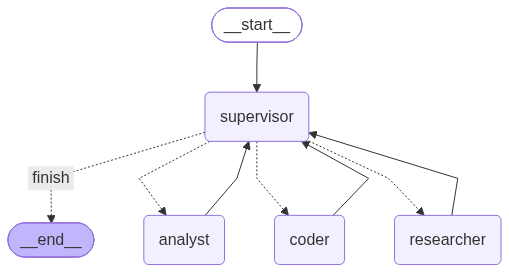

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 13. Ejecutar

En esta sección, definimos la pregunta inicial que el sistema multi-agente intentará resolver. Luego, invocamos el grafo con esta pregunta, iniciando el proceso. El sistema pasará por los diferentes agentes según las decisiones del supervisor hasta que la tarea se considere completada.

In [28]:
question = """
I have a dataset where the target variable is highly imbalanced.
How should I evaluate a binary classification model?
"""

result = graph.invoke(
    {
        "messages": [HumanMessage(content=question)],
        "next": "supervisor",
        "iterations": 0,   # ← NUEVO
    },
    config={"recursion_limit": 20},   # ← NUEVO: freno de emergencia (doble con el contador)
)

## 14. Ver el resultado

Una vez que el grafo ha terminado de procesar la pregunta, podemos examinar el resultado final. Este bucle itera sobre todos los mensajes generados durante la ejecución del grafo, mostrando el contenido de cada mensaje (HUMAN o AI) para que podamos ver la conversación completa y las respuestas de los agentes.

In [29]:
for message in result["messages"]:
    print(f"\n{message.type.upper()}:")
    print(message.content)


HUMAN:

I have a dataset where the target variable is highly imbalanced.
How should I evaluate a binary classification model?


AI:
**Research Summary – Evaluating Binary Classifiers on Highly Imbalanced Data**

---

### 1. Core Problem
When the positive class (e.g., fraud, disease) is rare, standard performance measures that treat all errors equally (e.g., overall accuracy) give a misleading picture. A model that always predicts the majority class can achieve high accuracy while being useless for the minority class.

### 2. Key Evaluation Concepts & Metrics

| Concept | Why It Matters | Recommended Metric(s) |
|---------|----------------|-----------------------|
| **Confusion‑matrix‑derived rates** | Separates true/false positives/negatives, exposing trade‑offs. | **Sensitivity (Recall, TP‑rate)**, **Specificity (TN‑rate)**, **Precision (Positive Predictive Value)** |
| **Balanced aggregation** | Averages that weight both classes equally. | **F1‑score** (harmonic mean of precision & 

## 15. (Opcional) Ver el paso a paso del grafo

Esta sección es opcional y útil para depurar o entender el flujo detallado del grafo. Al utilizar `graph.stream`, podemos ver el estado del grafo en cada paso de la ejecución. Esto nos permite observar cómo el supervisor toma decisiones, qué agente se activa y cómo se construyen los mensajes a lo largo del proceso, proporcionando una visión granular del comportamiento del sistema.

In [30]:
from langgraph.errors import GraphRecursionError

def pretty_stream(question: str):
    step = 0
    for state in graph.stream(
        {
            "messages": [HumanMessage(content=question)],
            "next": "supervisor",
            "iterations": 0,   # ← NUEVO
        },
        config={"recursion_limit": 20},   # ← NUEVO
    ):
        step += 1
        for node_name, update in state.items():
            print(f"\n{'='*60}")
            print(f"PASO {step} | nodo: {node_name}")
            print('='*60)

            if node_name == "supervisor":
                print(f"  → rutea a: {update.get('next')} (iteración {update.get('iterations')})")
                continue

            msgs = update.get("messages", [])
            for m in msgs:
                preview = (m.content or "(vacío)")[:200]
                print(f"  → {m.type} ({len(m.content or '')} chars): {preview}...")
    print(f"\n{'='*60}\nGRAFO TERMINADO (llegó a END)")

try:
    pretty_stream(question)
except GraphRecursionError as e:
    print(f"\n⚠️ GraphRecursionError: {e}")
    print("→ El supervisor nunca decidió 'finish'.")


PASO 1 | nodo: supervisor
  → rutea a: analyst (iteración 1)

PASO 2 | nodo: analyst
  → ai (9085 chars): ### 1. Why “accuracy” is misleading for imbalanced data  

If, for example, 95 % of the records belong to the **negative** class, a model that always predicts “negative” will achieve 95 % accuracy but...

PASO 3 | nodo: supervisor
  → rutea a: finish (iteración 2)

GRAFO TERMINADO (llegó a END)
